<a href="https://colab.research.google.com/github/sandip-thakuri01/Data-Science-Projects/blob/main/Employmentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Cleaning and and Preprocesing.  
The data Sometimes contains the missing values, null values, duplication etc which may cause problem in the processing of the data. So we clean the data . Some of the basic operation to done during the data cleaning are given  below  :


In [45]:
# Data Cleaning: Step-by-Step Guide and Notes

# 1. Handling Missing Values
# Missing values can skew analysis and model performance. It's essential to identify and handle them appropriately.

# Detect missing values:
# 'df.isnull()' returns a boolean mask indicating NaN locations.
# 'df.isnull().sum()' provides a count of NaN values per column.
# Example:
# print(df.isnull().sum())

# Strategies for handling missing values:
# a) Dropping rows/columns:
# 'df.dropna()' removes rows containing any NaN values.
# 'df.dropna(subset=['column_name'])' removes rows only if NaN is present in specified columns.
# Example:
# df_cleaned = df.dropna()
# df_age_cleaned = df.dropna(subset=['age'])

# b) Filling missing values:
# 'df.fillna(value)' replaces NaN with a specified value (e.g., 0, 'Unknown').
# 'df['column'].fillna(df['column'].mean())' fills NaN in a specific column with its mean (or median, mode).
# Example:
# df_filled_zero = df.fillna(0)
# df['age'].fillna(df['age'].mean(), inplace=True)


# 2. Removing Duplicate Rows
# Duplicates can lead to biased results and inflate dataset size. Removing them ensures uniqueness of observations.

# Detect duplicate rows:
# 'df.duplicated()' returns a boolean mask indicating duplicate rows (keeping the first occurrence by default).
# Example:
# print(df.duplicated().sum())

# Remove duplicate rows:
# 'df.drop_duplicates()' removes all duplicate rows, keeping only the first occurrence.
# Example:
# df_no_duplicates = df.drop_duplicates()


# 3. Correcting Data Types
# Ensuring columns have the correct data type (e.g., int, float, datetime) is vital for accurate operations and memory efficiency.

# Convert column to a specific data type:
# 'df['column'] = df['column'].astype(dtype)' converts the column to the specified type.
# Example:
# df['age'] = df['age'].astype(float)
# df['date_column'] = pd.to_datetime(df['date_column'])


# 4. Renaming Columns
# Clear and consistent column names improve readability and make data easier to work with.

# Rename columns:
# 'df.rename(columns={'old_name':'new_name'}, inplace=True)' renames specified columns.
# Example:
# df.rename(columns={'name':'full_name'}, inplace=True)


# 5. Applying Functions for Data Transformation
# Custom functions can be applied to columns for various transformations, feature engineering, or cleaning specific patterns.

# Apply a function to a column:
# 'df['new_column'] = df['existing_column'].apply(lambda x: function_logic)' applies a lambda or custom function.
# Example:
# df['score_pct'] = df['score'].apply(lambda x: x/100)


# Note: These are general examples. The actual cleaning steps and their order depend on the specific dataset and analysis goals.

We will use a data set from the kaggle and implement the data cleaning process.

In [46]:
import pandas as pd

In [47]:
emp = pd.read_csv('/content/occupazione.csv')
unemp = pd.read_csv('/content/disoccupazione.csv')


In [48]:
#clean column
emp.columns= emp.columns.str.replace(' ', '_')
unemp.columns= unemp.columns.str.replace(' ', '_')

In [49]:
emp.head() , unemp.head()

(  iso_code      country    sex    age  year  obs_value
 0      AFG  Afghanistan  Total    15+  2025     32.457
 1      AFG  Afghanistan  Total  15-24  2025     31.419
 2      AFG  Afghanistan  Total    25+  2025     33.056
 3      AFG  Afghanistan   Male    15+  2025     61.038
 4      AFG  Afghanistan   Male  15-24  2025     57.355,
   iso_code      country    sex    age  year  obs_value
 0      AFG  Afghanistan  Total    15+  2025     13.351
 1      AFG  Afghanistan  Total  15-24  2025     16.785
 2      AFG  Afghanistan  Total    25+  2025     11.340
 3      AFG  Afghanistan   Male    15+  2025     12.503
 4      AFG  Afghanistan   Male  15-24  2025     15.814)

In [50]:
df = pd.merge(
    emp[["iso_code", "country", "year", "obs_value"]],
    unemp[["iso_code", "country", "year", "obs_value"]],
    on=["iso_code", "country", "year"],
    how="inner"
)
df.head()

,iso_code,country,year,obs_value_x,obs_value_y
0,AFG,Afghanistan,2025,32.457,13.351
1,AFG,Afghanistan,2025,32.457,16.785
2,AFG,Afghanistan,2025,32.457,11.340
3,AFG,Afghanistan,2025,32.457,12.503
4,AFG,Afghanistan,2025,32.457,15.814


Since we have complete the cleaning and preprocessing phases. We will move to the analytical phases.

In [51]:
df_cleaned = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {df_cleaned.shape[0]}")

Number of rows after removing duplicates: 517248


In [52]:
df_cleaned = df_cleaned.rename(columns={'obs_value_x': 'employment_rate', 'obs_value_y': 'unemployment_rate'})
display(df_cleaned.head())

,iso_code,country,year,employment_rate,unemployment_rate
0,AFG,Afghanistan,2025,32.457,13.351
1,AFG,Afghanistan,2025,32.457,16.785
2,AFG,Afghanistan,2025,32.457,11.340
3,AFG,Afghanistan,2025,32.457,12.503
4,AFG,Afghanistan,2025,32.457,15.814


Now that we have cleaned the data by removing duplicates and renamed the columns for clarity, let's get a statistical overview of the dataframe before we delve into visualizations and correlations.

In [53]:
display(df_cleaned.describe())

,year,employment_rate,unemployment_rate
count,517248.000000,517248.000000,517248.000000
mean,2007.967584,52.641716,10.529754
std,10.081373,19.733124,10.195295
min,1991.000000,1.741000,0.027000
25%,1999.000000,38.739000,3.708000
50%,2008.000000,54.156000,7.180000
75%,2017.000000,67.200000,13.811000
max,2025.000000,98.535000,84.183000


In [54]:
print("\n DATA RANGE VALIDATION ")
emp_invalid = df_cleaned[(df_cleaned['employment_rate'] < 0) | (df_cleaned['employment_rate'] > 100)]
unemp_invalid = df_cleaned[(df_cleaned['unemployment_rate'] < 0) | (df_cleaned['unemployment_rate'] > 100)]

print(f"Invalid employment rates: {len(emp_invalid)}")
print(f"Invalid unemployment rates: {len(unemp_invalid)}")
print(f"Employment range: [{df_cleaned['employment_rate'].min():.2f}, {df_cleaned['employment_rate'].max():.2f}]")
print(f"Unemployment range: [{df_cleaned['unemployment_rate'].min():.2f}, {df_cleaned['unemployment_rate'].max():.2f}]")



 DATA RANGE VALIDATION 
Invalid employment rates: 0
Invalid unemployment rates: 0
Employment range: [1.74, 98.53]
Unemployment range: [0.03, 84.18]


In [55]:
print("\n OUTLIER DETECTION (IQR) ")
Q1_emp = df_cleaned['employment_rate'].quantile(0.25)
Q3_emp = df_cleaned['employment_rate'].quantile(0.75)
IQR_emp = Q3_emp - Q1_emp

outliers_emp = df_cleaned[
    (df_cleaned['employment_rate'] < Q1_emp - 1.5*IQR_emp) |
    (df_cleaned['employment_rate'] > Q3_emp + 1.5*IQR_emp)
]

print(f"Employment rate outliers: {len(outliers_emp)} ({len(outliers_emp)/len(df_cleaned)*100:.2f}%)")
print(f"Countries with outlier employment rates: {outliers_emp['country'].unique()[:10]}")


 OUTLIER DETECTION (IQR) 
Employment rate outliers: 0 (0.00%)
Countries with outlier employment rates: []


In [56]:
Q1_unemp = df_cleaned['unemployment_rate'].quantile(0.25)
Q3_unemp = df_cleaned['unemployment_rate'].quantile(0.75)
IQR_unemp = Q3_unemp - Q1_unemp

outliers_unemp = df_cleaned[
    (df_cleaned['unemployment_rate'] < Q1_unemp - 1.5*IQR_unemp) |
    (df_cleaned['unemployment_rate'] > Q3_unemp + 1.5*IQR_unemp)
]

print(f"Unemployment rate outliers: {len(outliers_unemp)} ({len(outliers_unemp)/len(df_cleaned)*100:.2f}%)")

Unemployment rate outliers: 32031 (6.19%)


In [57]:
# Employment Rate
print("\n--- Employment Rate ---")
emp_stats = df_cleaned['employment_rate'].describe()
print(emp_stats)
print(f"Skewness: {df_cleaned['employment_rate'].skew():.4f}")
print(f"Kurtosis: {df_cleaned['employment_rate'].kurtosis():.4f}")
print(f"Coefficient of Variation: {(df_cleaned['employment_rate'].std() / df_cleaned['employment_rate'].mean() * 100):.2f}%")




--- Employment Rate ---
count    517248.000000
mean         52.641716
std          19.733124
min           1.741000
25%          38.739000
50%          54.156000
75%          67.200000
max          98.535000
Name: employment_rate, dtype: float64
Skewness: -0.2061
Kurtosis: -0.5874
Coefficient of Variation: 37.49%


In [58]:
print("\n--- Unemployment Rate ---")
unemp_stats = df_cleaned['unemployment_rate'].describe()
print(unemp_stats)
print(f"Skewness: {df_cleaned['unemployment_rate'].skew():.4f}")
print(f"Kurtosis: {df_cleaned['unemployment_rate'].kurtosis():.4f}")
print(f"Coefficient of Variation: {(df_cleaned['unemployment_rate'].std() / df_cleaned['unemployment_rate'].mean() * 100):.2f}%")



--- Unemployment Rate ---
count    517248.000000
mean         10.529754
std          10.195295
min           0.027000
25%           3.708000
50%           7.180000
75%          13.811000
max          84.183000
Name: unemployment_rate, dtype: float64
Skewness: 2.1425
Kurtosis: 6.0878
Coefficient of Variation: 96.82%


### Distribution of Employment and Unemployment Rates

Let's visualize the distribution of `employment_rate` and `unemployment_rate` using histograms to understand their spread and central tendency.

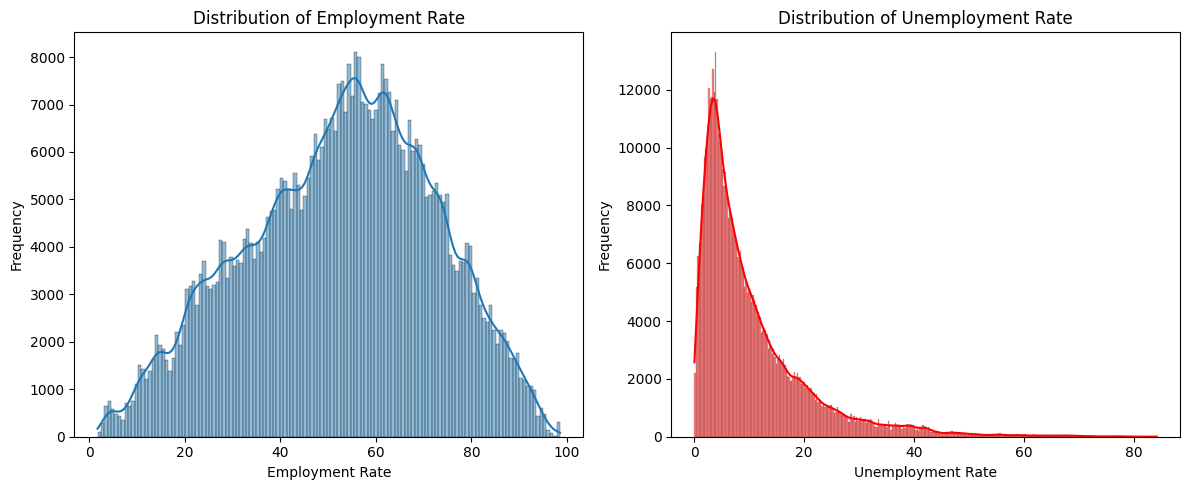

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['employment_rate'], kde=True)
plt.title('Distribution of Employment Rate')
plt.xlabel('Employment Rate')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['unemployment_rate'], kde=True, color='red')
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [60]:
from scipy.stats import shapiro, normaltest

print("\n=== NORMALITY TESTS ===")

# Test employment rate
# Note: Shapiro-Wilk works best with sample size < 5000
sample_size = min(5000, len(df_cleaned))
emp_sample = df_cleaned['employment_rate'].sample(sample_size, random_state=42)

stat_emp, p_emp = shapiro(emp_sample)
print(f"\nEmployment Rate - Shapiro-Wilk Test:")
print(f"  Statistic: {stat_emp:.6f}")
print(f"  P-value: {p_emp:.6f}")
print(f"  Result: {'NOT normally distributed' if p_emp < 0.05 else 'Normally distributed'}")



=== NORMALITY TESTS ===

Employment Rate - Shapiro-Wilk Test:
  Statistic: 0.990014
  P-value: 0.000000
  Result: NOT normally distributed


In [61]:
unemp_sample = df_cleaned['unemployment_rate'].sample(sample_size, random_state=42)
stat_unemp, p_unemp = shapiro(unemp_sample)
print(f"\nUnemployment Rate - Shapiro-Wilk Test:")
print(f"  Statistic: {stat_unemp:.6f}")
print(f"  P-value: {p_unemp:.6f}")
print(f"  Result: {'NOT normally distributed' if p_unemp < 0.05 else 'Normally distributed'}")

print("\n⚠️  Since data is NOT normally distributed, use:")
print("   - Spearman correlation (instead of Pearson)")
print("   - Mann-Whitney U test (instead of t-test)")
print("   - Kruskal-Wallis (instead of ANOVA)")



Unemployment Rate - Shapiro-Wilk Test:
  Statistic: 0.784508
  P-value: 0.000000
  Result: NOT normally distributed

⚠️  Since data is NOT normally distributed, use:
   - Spearman correlation (instead of Pearson)
   - Mann-Whitney U test (instead of t-test)
   - Kruskal-Wallis (instead of ANOVA)


### Correlation between Employment and Unemployment Rates

Now, let's calculate the Pearson correlation coefficient between the `employment_rate` and `unemployment_rate` to quantify their linear relationship.

In [62]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

print("\n=== COMPREHENSIVE CORRELATION ANALYSIS ===")

# Pearson Correlation (parametric - assumes normality)
pearson_r, pearson_p = pearsonr(df_cleaned['employment_rate'],
                                 df_cleaned['unemployment_rate'])

print(f"\n1. Pearson Correlation (parametric):")
print(f"   Coefficient (r): {pearson_r:.4f}")
print(f"   P-value: {pearson_p:.6f}")
print(f"   R-squared (R²): {pearson_r**2:.4f}")
print(f"   Significance: {'SIGNIFICANT' if pearson_p < 0.05 else 'NOT significant'} at α=0.05")
print(f"   Interpretation: {pearson_r**2*100:.2f}% of variance explained")

# Spearman Correlation (non-parametric - better for non-normal data)
spearman_r, spearman_p = spearmanr(df_cleaned['employment_rate'],
                                    df_cleaned['unemployment_rate'])

print(f"\n2. Spearman Correlation (non-parametric - RECOMMENDED):")
print(f"   Coefficient (ρ): {spearman_r:.4f}")
print(f"   P-value: {spearman_p:.6f}")
print(f"   Significance: {'SIGNIFICANT' if spearman_p < 0.05 else 'NOT significant'} at α=0.05")



=== COMPREHENSIVE CORRELATION ANALYSIS ===

1. Pearson Correlation (parametric):
   Coefficient (r): -0.3376
   P-value: 0.000000
   R-squared (R²): 0.1140
   Significance: SIGNIFICANT at α=0.05
   Interpretation: 11.40% of variance explained

2. Spearman Correlation (non-parametric - RECOMMENDED):
   Coefficient (ρ): -0.3595
   P-value: 0.000000
   Significance: SIGNIFICANT at α=0.05


In [63]:
z = np.arctanh(pearson_r)
se = 1 / np.sqrt(len(df_cleaned) - 3)
z_critical = 1.96  # 95% CI
ci_low = np.tanh(z - z_critical * se)
ci_high = np.tanh(z + z_critical * se)
print(f"\n3. 95% Confidence Interval for Pearson r:")
print(f"   [{ci_low:.4f}, {ci_high:.4f}]")



3. 95% Confidence Interval for Pearson r:
   [-0.3401, -0.3352]


In [64]:
abs_r = abs(pearson_r)
if abs_r < 0.3:
    strength = "WEAK"
elif abs_r < 0.7:
    strength = "MODERATE"
else:
    strength = "STRONG"

print(f"\n4. Interpretation:")
print(f"   This is a {strength} negative correlation")
print(f"   As employment rate increases, unemployment rate decreases")


4. Interpretation:
   This is a MODERATE negative correlation
   As employment rate increases, unemployment rate decreases


### Scatter Plot: Employment Rate vs. Unemployment Rate

Let's visualize the relationship between `employment_rate` and `unemployment_rate` using a scatter plot. This will help us to see if there's any visible pattern or clustering.

In [1]:
from scipy.stats import linregress

plt.figure(figsize=(12, 7))
sns.scatterplot(x='employment_rate', y='unemployment_rate', data=df_cleaned, alpha=0.5, s=20)

# Add regression line
slope, intercept, r_value, p_value, std_err = linregress(
    df_cleaned['employment_rate'],
    df_cleaned['unemployment_rate']
)

x_line = np.array([df_cleaned['employment_rate'].min(),
                   df_cleaned['employment_rate'].max()])
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'r-', linewidth=2,
         label=f'y = {slope:.3f}x + {intercept:.3f}')

# Add statistics box
textstr = f'Pearson r = {pearson_r:.4f}\nR² = {pearson_r**2:.4f}\np-value < 0.001\n95% CI: [{ci_low:.3f}, {ci_high:.3f}]'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', bbox=props)

plt.title('Employment Rate vs. Unemployment Rate\n(with Statistical Annotations)', fontsize=14)
plt.xlabel('Employment Rate (%)', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

In [ ]:
from scipy import stats

print("\n COUNTRY COMPARISON WITH CONFIDENCE INTERVALS ")

# Calculate mean + 95% CI for each country
country_stats = df_cleaned.groupby('country')['employment_rate'].agg([
    'count',
    'mean',
    'std',
    ('sem', lambda x: stats.sem(x)),  # Standard error
    ('ci_lower', lambda x: x.mean() - stats.t.ppf(0.975, len(x)-1) * stats.sem(x)),
    ('ci_upper', lambda x: x.mean() + stats.t.ppf(0.975, len(x)-1) * stats.sem(x))
]).reset_index()
top_10 = country_stats.sort_values('mean', ascending=False).head(10)

print("\nTop 10 Countries with 95% Confidence Intervals:")
print(top_10[['country', 'count', 'mean', 'ci_lower', 'ci_upper']].to_string(index=False))

# Visualization with error bars
plt.figure(figsize=(12, 8))

y_pos = np.arange(len(top_10))
means = top_10['mean'].values
errors = top_10['mean'].values - top_10['ci_lower'].values

plt.barh(y_pos, means, xerr=errors, alpha=0.7, capsize=5,
         color=plt.cm.viridis(np.linspace(0, 1, len(top_10))))
plt.yticks(y_pos, top_10['country'].values)
plt.xlabel('Employment Rate (%) with 95% CI')
plt.title('Top 10 Countries by Employment Rate\n(Error bars show 95% Confidence Intervals)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()



### Variation of Employment and Unemployment Rates by Country

Let's analyze how employment and unemployment rates vary across different countries by calculating the average rates for each country.

In [23]:
country_rates = df_cleaned.groupby('country')[['employment_rate', 'unemployment_rate']].mean().reset_index()

print("Top 10 Countries by Average Employment Rate:")
display(country_rates.sort_values(by='employment_rate', ascending=False).head(10))

print("\nBottom 10 Countries by Average Employment Rate:")
display(country_rates.sort_values(by='employment_rate', ascending=True).head(10))

print("\nTop 10 Countries by Average Unemployment Rate:")
display(country_rates.sort_values(by='unemployment_rate', ascending=False).head(10))

print("\nBottom 10 Countries by Average Unemployment Rate:")
display(country_rates.sort_values(by='unemployment_rate', ascending=True).head(10))

Top 10 Countries by Average Employment Rate:


,country,employment_rate,unemployment_rate
160,"Tanzania, United Republic of",81.709657,3.110803
97,Madagascar,80.707365,4.205502
147,Solomon Islands,80.437479,1.813987
27,Cambodia,79.175711,0.727495
85,Korea (the Democratic People's Republic of),77.542946,4.476498
117,Nigeria,77.061197,4.694971
109,Mozambique,76.957787,4.396667
25,Burundi,76.885317,2.355817
24,Burkina Faso,75.188625,3.870549
116,Niger,75.110703,1.450981



Bottom 10 Countries by Average Employment Rate:


,country,employment_rate,unemployment_rate
139,Sao Tome and Principe,20.749854,13.732286
45,Djibouti,21.297410,39.163927
148,Somalia,25.382117,23.736721
82,Jordan,29.701483,22.532679
122,Palestine (State of),31.217424,22.314271
2,Algeria,31.998317,22.718984
93,Libya,32.274108,29.443835
180,Yemen,32.745702,16.768940
118,North Macedonia,33.192578,34.675041
107,Montenegro,33.471133,29.245210



Top 10 Countries by Average Unemployment Rate:


,country,employment_rate,unemployment_rate
45,Djibouti,21.297410,39.163927
118,North Macedonia,33.192578,34.675041
53,Eswatini,35.399244,32.337778
149,South Africa,36.843397,31.912740
19,Bosnia and Herzegovina,33.959673,30.327835
93,Libya,32.274108,29.443835
107,Montenegro,33.471133,29.245210
111,Namibia,40.797692,25.869641
36,Congo,49.635898,25.038765
137,Saint Vincent and the Grenadines,47.897917,24.843584



Bottom 10 Countries by Average Unemployment Rate:


,country,employment_rate,unemployment_rate
27,Cambodia,79.175711,0.727495
31,Chad,62.164613,0.958867
116,Niger,75.110703,1.450981
16,Benin,69.116022,1.564876
130,Qatar,72.657048,1.581771
110,Myanmar,63.405044,1.582232
147,Solomon Islands,80.437479,1.813987
101,Mali,66.632333,1.920044
161,Thailand,64.874792,2.161551
88,Lao People's Democratic Republic,59.623213,2.195786


### Visualization of Country-wise Rates

To better visualize the variation, let's plot the top and bottom countries by their average employment and unemployment rates.

/tmp/ipykernel_149/1810714119.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employment_rate', y='country', data=country_rates.sort_values(by='employment_rate', ascending=False).head(10), ax=axes[0], palette='viridis')
/tmp/ipykernel_149/1810714119.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='unemployment_rate', y='country', data=country_rates.sort_values(by='unemployment_rate', ascending=False).head(10), ax=axes[1], palette='magma')


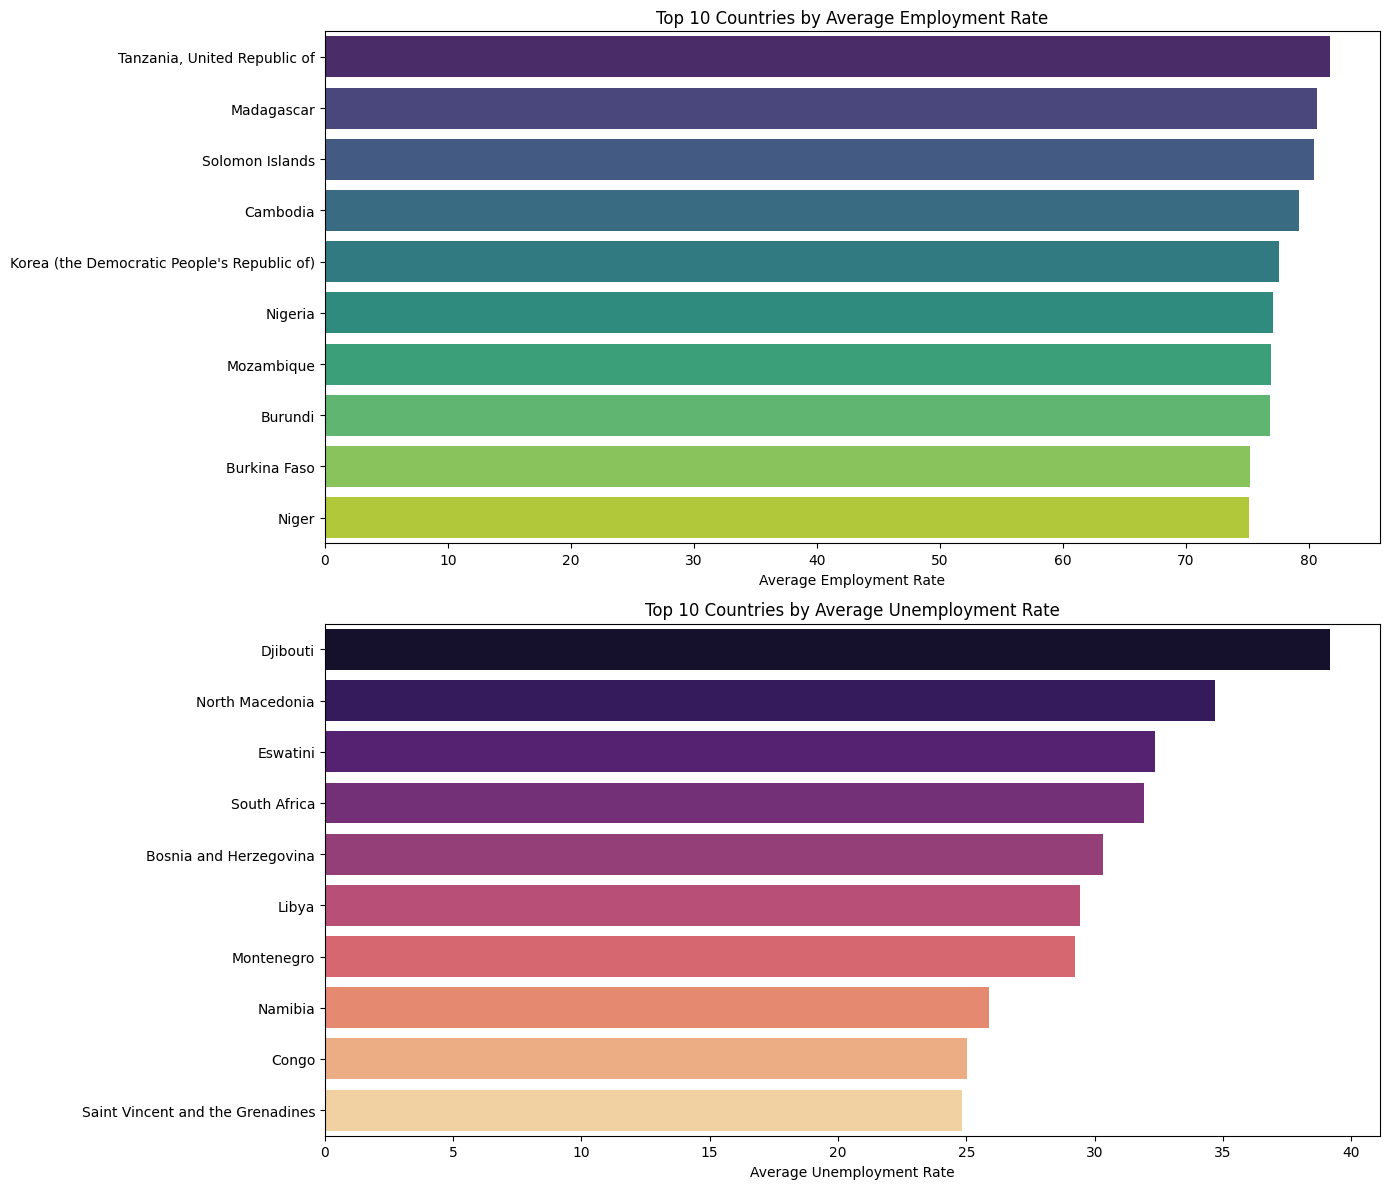

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 10 Employment Rate
sns.barplot(x='employment_rate', y='country', data=country_rates.sort_values(by='employment_rate', ascending=False).head(10), ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Countries by Average Employment Rate')
axes[0].set_xlabel('Average Employment Rate')
axes[0].set_ylabel('')

# Top 10 Unemployment Rate
sns.barplot(x='unemployment_rate', y='country', data=country_rates.sort_values(by='unemployment_rate', ascending=False).head(10), ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Countries by Average Unemployment Rate')
axes[1].set_xlabel('Average Unemployment Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [25]:
unique_countries = df_cleaned['country'].unique()
print("List of unique countries in the dataset:")
for country in unique_countries:
    print(f"- {country}")

List of unique countries in the dataset:
- Afghanistan
- Angola
- Albania
- United Arab Emirates
- Argentina
- Armenia
- Australia
- Austria
- Azerbaijan
- Burundi
- Belgium
- Benin
- Burkina Faso
- Bangladesh
- Bulgaria
- Bahrain
- Bahamas
- Bosnia and Herzegovina
- Belarus
- Belize
- Bolivia (Plurinational State of)
- Brazil
- Barbados
- Brunei Darussalam
- Bhutan
- Botswana
- Central African Republic
- Canada
- Switzerland
- Chile
- China
- Côte d'Ivoire
- Cameroon
- Congo, Democratic Republic of the
- Congo
- Colombia
- Comoros
- Cabo Verde
- Costa Rica
- Cuba
- Cyprus
- Czechia
- Germany
- Djibouti
- Denmark
- Dominican Republic
- Algeria
- Ecuador
- Egypt
- Eritrea
- Western Sahara
- Spain
- Estonia
- Ethiopia
- Finland
- Fiji
- France
- Gabon
- United Kingdom of Great Britain and Northern Ireland
- Georgia
- Ghana
- Guinea
- Gambia
- Guinea-Bissau
- Equatorial Guinea
- Greece
- Guatemala
- Guyana
- Hong Kong, China
- Honduras
- Croatia
- Haiti
- Hungary
- Indonesia
- India
- Ire

In [26]:
south_asian_countries = [
    'Afghanistan',
    'Bangladesh',
    'Bhutan',
    'India',
    'Maldives',
    'Nepal',
    'Pakistan',
    'Sri Lanka'
]

south_asia_df = df_cleaned[df_cleaned['country'].isin(south_asian_countries)]

# Calculate average unemployment rate for South Asian countries
south_asia_unemp_rates = south_asia_df.groupby('country')['unemployment_rate'].mean().reset_index()
south_asia_unemp_rates = south_asia_unemp_rates.sort_values(by='unemployment_rate', ascending=False)

print("Average Unemployment Rates in South Asian Countries:")
display(south_asia_unemp_rates)

Average Unemployment Rates in South Asian Countries:


,country,unemployment_rate
5,Nepal,12.979886
7,Sri Lanka,12.416610
0,Afghanistan,10.749803
3,India,10.740565
4,Maldives,6.760632
1,Bangladesh,5.108667
2,Bhutan,4.733440
6,Pakistan,2.509471


/tmp/ipykernel_149/814609298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='unemployment_rate', y='country', data=south_asia_unemp_rates, palette='viridis')


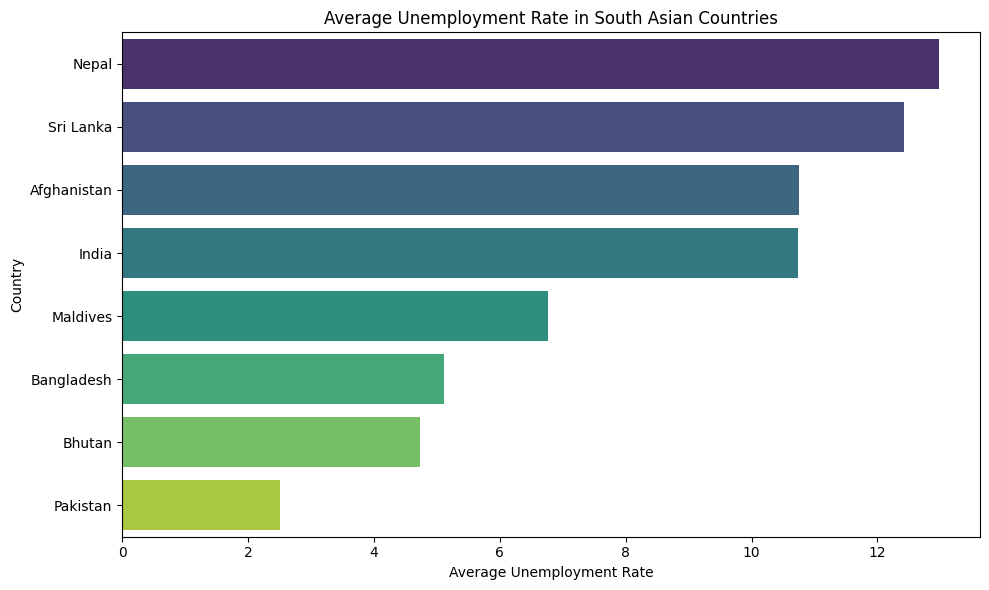

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='unemployment_rate', y='country', data=south_asia_unemp_rates, palette='viridis')
plt.title('Average Unemployment Rate in South Asian Countries')
plt.xlabel('Average Unemployment Rate')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [28]:
landlocked_countries = [
    'Afghanistan', 'Armenia', 'Azerbaijan', 'Belarus', 'Bhutan',
    'Bolivia (Plurinational State of)', 'Botswana', 'Burkina Faso', 'Burundi',
    'Central African Republic', 'Chad', 'Ethiopia', 'Hungary', 'Kazakhstan',
    'Kyrgyzstan', 'Lao People\'s Democratic Republic', 'Lesotho', 'Malawi', 'Mali',
    'Republic of Moldova', 'Mongolia', 'Nepal', 'Niger', 'North Macedonia',
    'Paraguay', 'Rwanda', 'Serbia', 'Slovakia', 'South Sudan', 'Switzerland',
    'Tajikistan', 'Turkmenistan', 'Uganda', 'Uzbekistan', 'Zambia', 'Zimbabwe'
]

# Filter the DataFrame for these landlocked countries
landlocked_df = df_cleaned[df_cleaned['country'].isin(landlocked_countries)]

# Calculate average unemployment rates for landlocked countries
landlocked_unemp_rates = landlocked_df.groupby('country')['unemployment_rate'].mean().reset_index()
landlocked_unemp_rates = landlocked_unemp_rates.sort_values(by='unemployment_rate', ascending=False)

print("Average Unemployment Rates for Landlocked Countries (including Nepal):")
display(landlocked_unemp_rates)

Average Unemployment Rates for Landlocked Countries (including Nepal):


,country,unemployment_rate
22,North Macedonia,34.675041
6,Botswana,23.944987
26,Serbia,20.656463
16,Lesotho,18.035083
27,Slovakia,15.976032
1,Armenia,15.496784
28,South Sudan,13.753189
20,Nepal,12.979886
34,Zambia,12.963349
25,Rwanda,12.804263


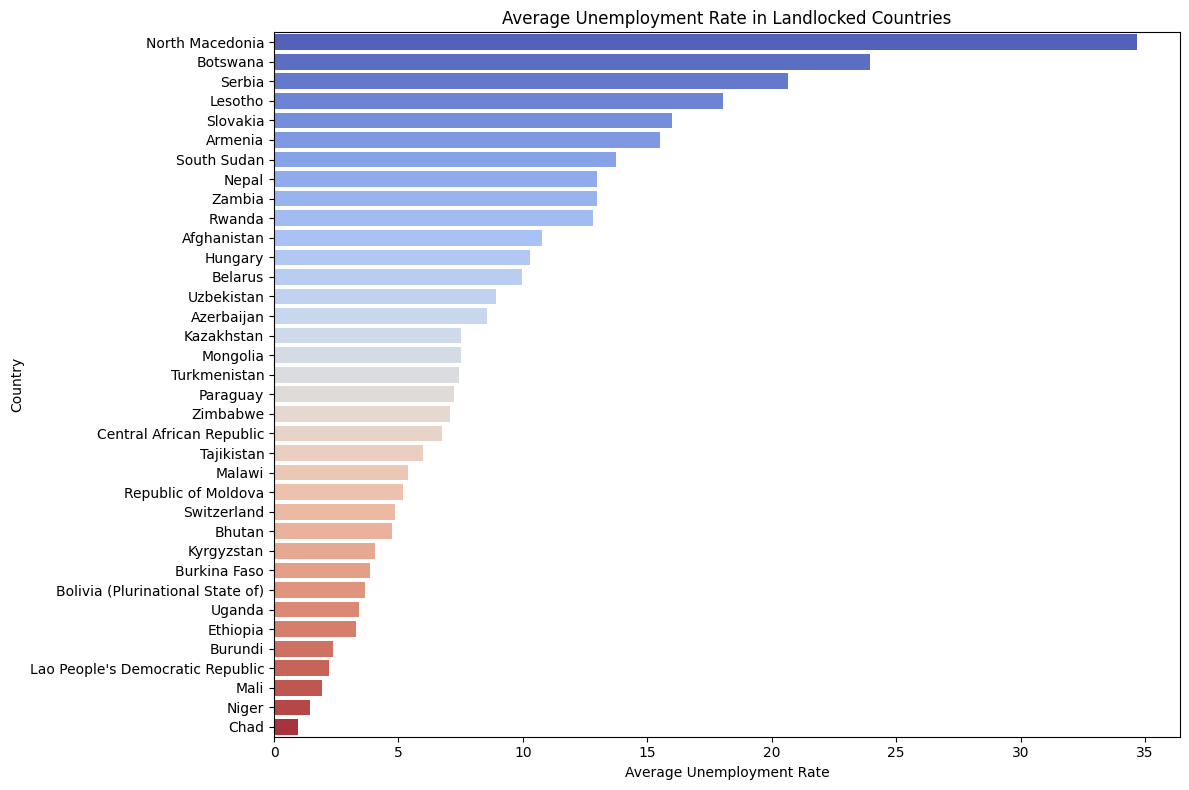

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x='unemployment_rate', y='country', data=landlocked_unemp_rates, hue='country', palette='coolwarm', legend=False)
plt.title('Average Unemployment Rate in Landlocked Countries')
plt.xlabel('Average Unemployment Rate')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import ttest_1samp

print("\n=== SOUTH ASIA vs GLOBAL COMPARISON ===")

# Get South Asian data
south_asia_unemp = south_asia_df['unemployment_rate']
global_mean_unemp = df_cleaned['unemployment_rate'].mean()

# One-sample t-test
t_stat, p_value = ttest_1samp(south_asia_unemp, global_mean_unemp)

print(f"\nGlobal average unemployment rate: {global_mean_unemp:.4f}%")
print(f"South Asia average unemployment rate: {south_asia_unemp.mean():.4f}%")
print(f"Difference: {south_asia_unemp.mean() - global_mean_unemp:.4f} percentage points")

print(f"\nOne-Sample t-test:")
print(f"  Null hypothesis: South Asia unemployment = Global average")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.6f}")

if p_value < 0.05:
    if south_asia_unemp.mean() > global_mean_unemp:
        print(f"  Result: South Asia has SIGNIFICANTLY HIGHER unemployment than global average")
    else:
        print(f"  Result: South Asia has SIGNIFICANTLY LOWER unemployment than global average")
else:
    print(f"  Result: No significant difference from global average")

# Effect size (Cohen's d)
cohens_d = (south_asia_unemp.mean() - global_mean_unemp) / south_asia_unemp.std()
print(f"\nEffect Size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print(f"  Interpretation: SMALL effect")
elif abs(cohens_d) < 0.8:
    print(f"  Interpretation: MEDIUM effect")
else:
    print(f"  Interpretation: LARGE effect")



=== SOUTH ASIA vs GLOBAL COMPARISON ===

Global average unemployment rate: 10.5298%
South Asia average unemployment rate: 8.2606%
Difference: -2.2692 percentage points

One-Sample t-test:
  Null hypothesis: South Asia unemployment = Global average
  t-statistic: -47.2089
  P-value: 0.000000
  Result: South Asia has SIGNIFICANTLY LOWER unemployment than global average

Effect Size (Cohen's d): -0.3139
  Interpretation: MEDIUM effect



=== MULTIPLE REGRESSION ANALYSIS ===
Predicting Unemployment Rate from Employment Rate and Year

Model Performance:
  R-squared: 0.1145
  Adjusted R-squared: 0.1145
  RMSE: 9.5940

Coefficients:
  Intercept: 63.7607
  Employment Rate: -0.1750
  Year: -0.0219

Interpretation:
  - A 1% increase in employment rate is associated with a -0.1750% change in unemployment
  - Each year is associated with a -0.0219% change in unemployment
  - The model explains 11.45% of variance in unemployment rate


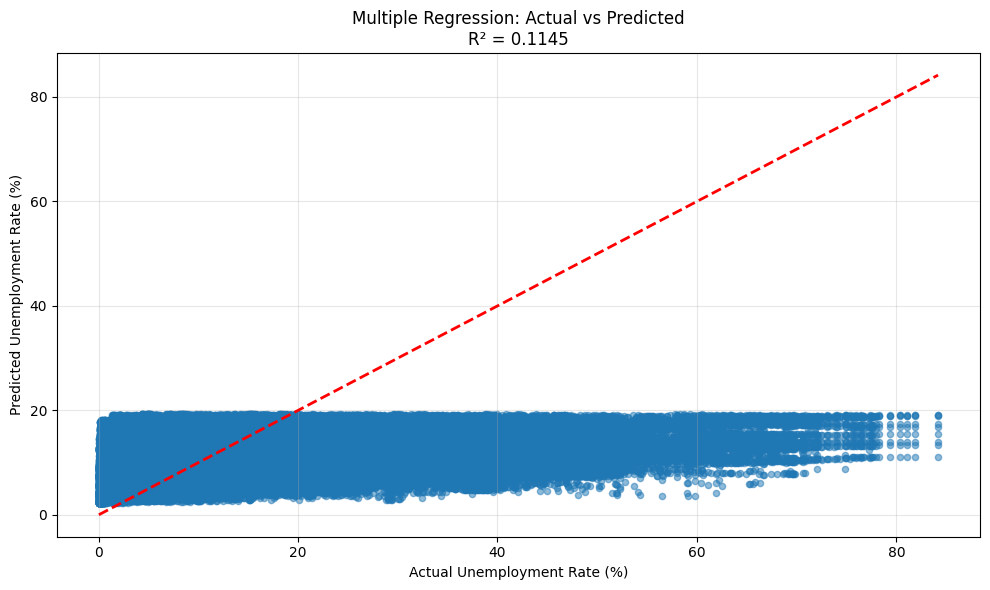

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

print("\n=== MULTIPLE REGRESSION ANALYSIS ===")
print("Predicting Unemployment Rate from Employment Rate and Year")

# Prepare data
df_reg = df_cleaned[['employment_rate', 'year', 'unemployment_rate']].dropna()
X = df_reg[['employment_rate', 'year']]
y = df_reg['unemployment_rate']

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Model statistics
r2 = r2_score(y, y_pred)
adj_r2 = 1 - (1 - r2) * (len(df_reg) - 1) / (len(df_reg) - X.shape[1] - 1)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nModel Performance:")
print(f"  R-squared: {r2:.4f}")
print(f"  Adjusted R-squared: {adj_r2:.4f}")
print(f"  RMSE: {rmse:.4f}")

print(f"\nCoefficients:")
print(f"  Intercept: {model.intercept_:.4f}")
print(f"  Employment Rate: {model.coef_[0]:.4f}")
print(f"  Year: {model.coef_[1]:.4f}")

print(f"\nInterpretation:")
print(f"  - A 1% increase in employment rate is associated with a {model.coef_[0]:.4f}% change in unemployment")
print(f"  - Each year is associated with a {model.coef_[1]:.4f}% change in unemployment")
print(f"  - The model explains {r2*100:.2f}% of variance in unemployment rate")

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5, s=20)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Actual Unemployment Rate (%)')
plt.ylabel('Predicted Unemployment Rate (%)')
plt.title(f'Multiple Regression: Actual vs Predicted\nR² = {r2:.4f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
country_avg_employment = df_cleaned.groupby('country')['employment_rate'].mean().reset_index()
country_avg_employment = country_avg_employment.sort_values(by='employment_rate', ascending=False)

print("Top 10 Countries by Average Employment Rate:")
display(country_avg_employment.head(10))

print("\nBottom 10 Countries by Average Employment Rate:")
display(country_avg_employment.tail(10))

Top 10 Countries by Average Employment Rate:


,country,employment_rate
160,"Tanzania, United Republic of",81.709657
97,Madagascar,80.707365
147,Solomon Islands,80.437479
27,Cambodia,79.175711
85,Korea (the Democratic People's Republic of),77.542946
117,Nigeria,77.061197
109,Mozambique,76.957787
25,Burundi,76.885317
24,Burkina Faso,75.188625
116,Niger,75.110703



Bottom 10 Countries by Average Employment Rate:


,country,employment_rate
107,Montenegro,33.471133
118,North Macedonia,33.192578
180,Yemen,32.745702
93,Libya,32.274108
2,Algeria,31.998317
122,Palestine (State of),31.217424
82,Jordan,29.701483
148,Somalia,25.382117
45,Djibouti,21.297410
139,Sao Tome and Principe,20.749854


/tmp/ipykernel_149/2843028098.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employment_rate', y='country', data=country_avg_employment.head(10), ax=axes[0], palette='viridis')
/tmp/ipykernel_149/2843028098.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employment_rate', y='country', data=country_avg_employment.tail(10).sort_values(by='employment_rate', ascending=True), ax=axes[1], palette='magma')


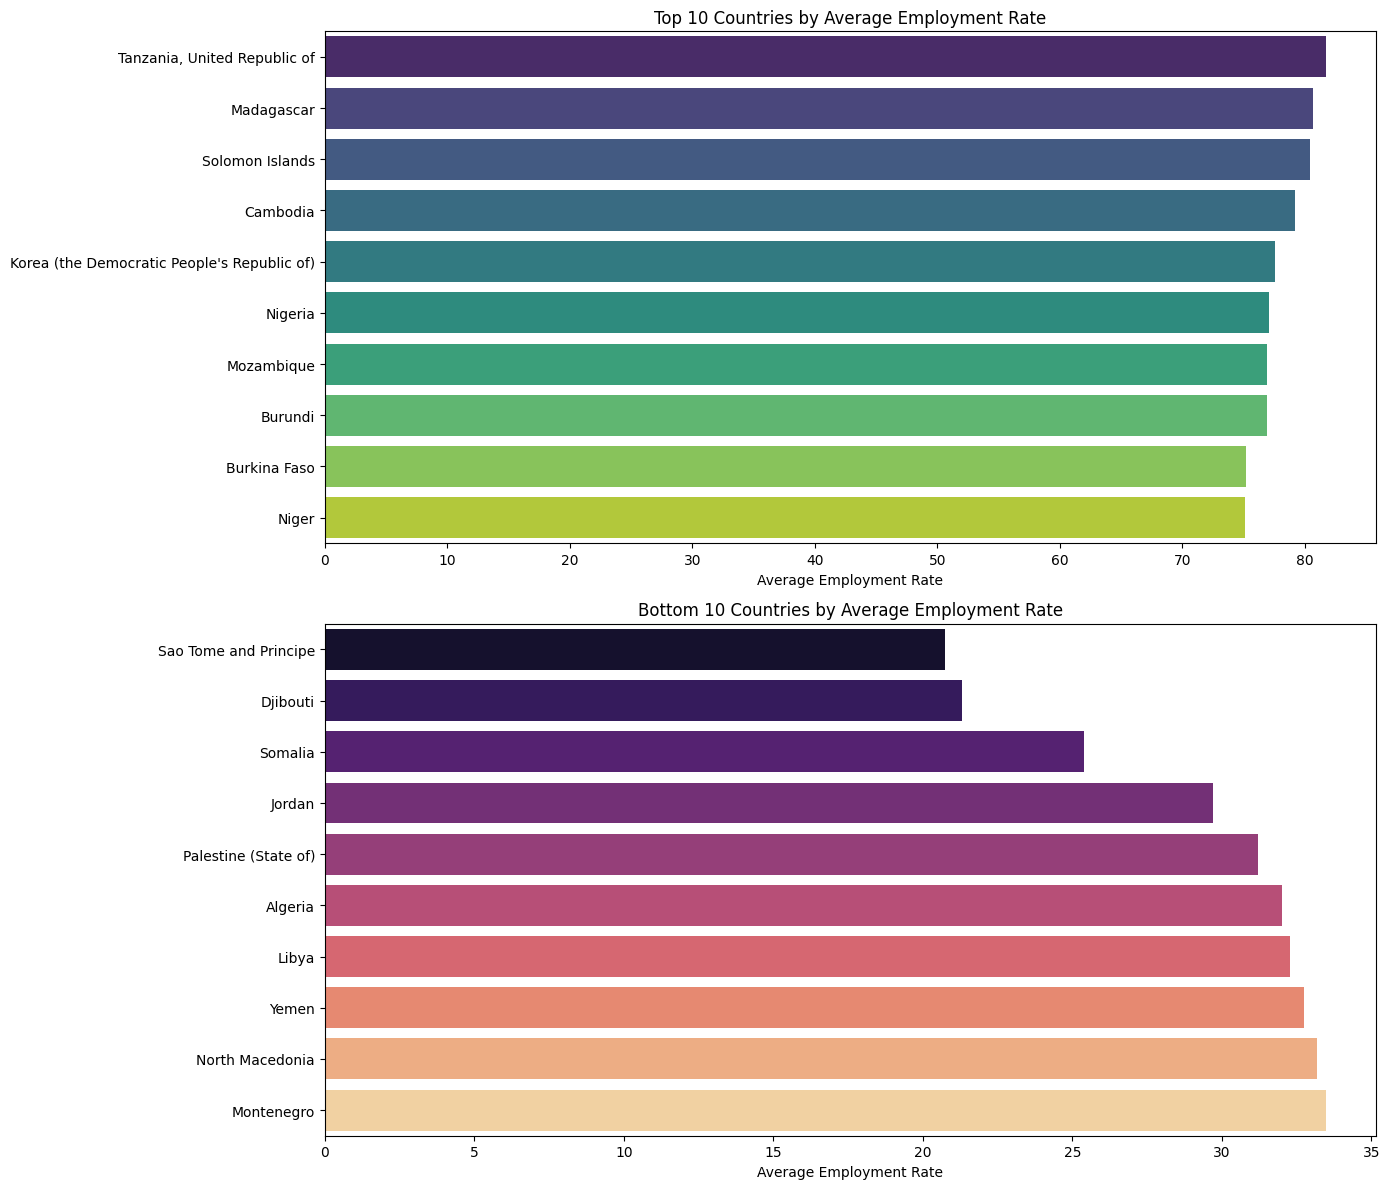

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 10 Employment Rate
sns.barplot(x='employment_rate', y='country', data=country_avg_employment.head(10), ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Countries by Average Employment Rate')
axes[0].set_xlabel('Average Employment Rate')
axes[0].set_ylabel('')

# Bottom 10 Employment Rate
sns.barplot(x='employment_rate', y='country', data=country_avg_employment.tail(10).sort_values(by='employment_rate', ascending=True), ax=axes[1], palette='magma')
axes[1].set_title('Bottom 10 Countries by Average Employment Rate')
axes[1].set_xlabel('Average Employment Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [34]:
display(df_cleaned['employment_rate'].describe())

,employment_rate
count,517248.000000
mean,52.641716
std,19.733124
min,1.741000
25%,38.739000
50%,54.156000
75%,67.200000
max,98.535000


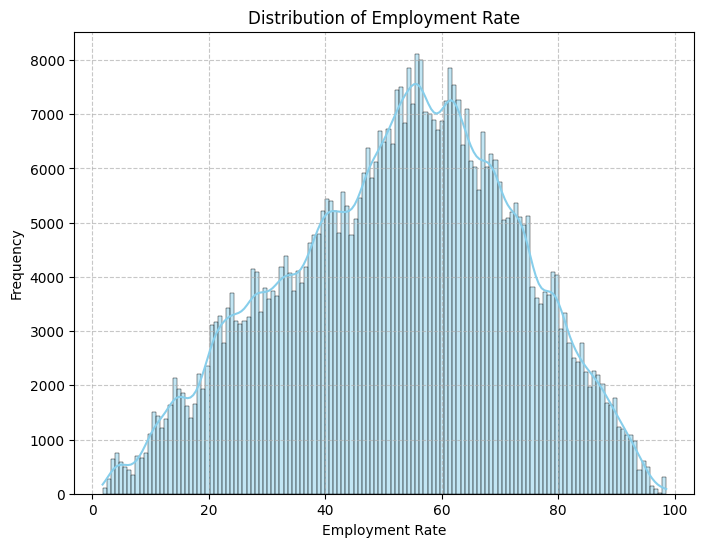

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df_cleaned['employment_rate'], kde=True, color='skyblue')
plt.title('Distribution of Employment Rate')
plt.xlabel('Employment Rate')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [36]:
nepal_df = df_cleaned[df_cleaned['country'] == 'Nepal']
nepal_yearly_trends = nepal_df.groupby('year')[['employment_rate', 'unemployment_rate']].mean().reset_index()

display(nepal_yearly_trends.head())

,year,employment_rate,unemployment_rate
0,1991,35.435778,12.648333
1,1992,35.452333,12.644889
2,1993,35.452556,12.659556
3,1994,35.449889,12.624111
4,1995,35.421889,12.644444


In [37]:
from scipy.stats import linregress

print("\n=== NEPAL TIME SERIES TREND ANALYSIS ===")

# Test employment rate trend
slope_emp, intercept_emp, r_emp, p_emp, se_emp = linregress(
    nepal_yearly_trends['year'],
    nepal_yearly_trends['employment_rate']
)

print(f"\nEmployment Rate Trend:")
print(f"  Slope: {slope_emp:.6f} percentage points per year")
print(f"  R-squared: {r_emp**2:.4f}")
print(f"  P-value: {p_emp:.6f}")
print(f"  Trend: {'SIGNIFICANT' if p_emp < 0.05 else 'NOT significant'}")

if slope_emp > 0:
    print(f"  Interpretation: Employment rate is INCREASING by {abs(slope_emp):.4f}% per year")
elif slope_emp < 0:
    print(f"  Interpretation: Employment rate is DECREASING by {abs(slope_emp):.4f}% per year")

# Test unemployment rate trend
slope_unemp, intercept_unemp, r_unemp, p_unemp, se_unemp = linregress(
    nepal_yearly_trends['year'],
    nepal_yearly_trends['unemployment_rate']
)

print(f"\nUnemployment Rate Trend:")
print(f"  Slope: {slope_unemp:.6f} percentage points per year")
print(f"  R-squared: {r_unemp**2:.4f}")
print(f"  P-value: {p_unemp:.6f}")
print(f"  Trend: {'SIGNIFICANT' if p_unemp < 0.05 else 'NOT significant'}")

if slope_unemp > 0:
    print(f"  Interpretation: Unemployment rate is INCREASING by {abs(slope_unemp):.4f}% per year")
elif slope_unemp < 0:
    print(f"  Interpretation: Unemployment rate is DECREASING by {abs(slope_unemp):.4f}% per year")

# Forecast next 3 years
future_years = np.arange(nepal_yearly_trends['year'].max() + 1,
                         nepal_yearly_trends['year'].max() + 4)
forecast_emp = slope_emp * future_years + intercept_emp
forecast_unemp = slope_unemp * future_years + intercept_unemp

print(f"\n3-Year Forecast for Nepal:")
print(f"{'Year':<10} {'Employment Rate':<20} {'Unemployment Rate'}")
print("-" * 50)
for year, emp, unemp in zip(future_years, forecast_emp, forecast_unemp):
    print(f"{year:<10} {emp:<20.2f} {unemp:.2f}")



=== NEPAL TIME SERIES TREND ANALYSIS ===

Employment Rate Trend:
  Slope: -0.082348 percentage points per year
  R-squared: 0.7341
  P-value: 0.000000
  Trend: SIGNIFICANT
  Interpretation: Employment rate is DECREASING by 0.0823% per year

Unemployment Rate Trend:
  Slope: 0.034217 percentage points per year
  R-squared: 0.2760
  P-value: 0.001191
  Trend: SIGNIFICANT
  Interpretation: Unemployment rate is INCREASING by 0.0342% per year

3-Year Forecast for Nepal:
Year       Employment Rate      Unemployment Rate
--------------------------------------------------
2026       33.22                13.60
2027       33.14                13.63
2028       33.05                13.66


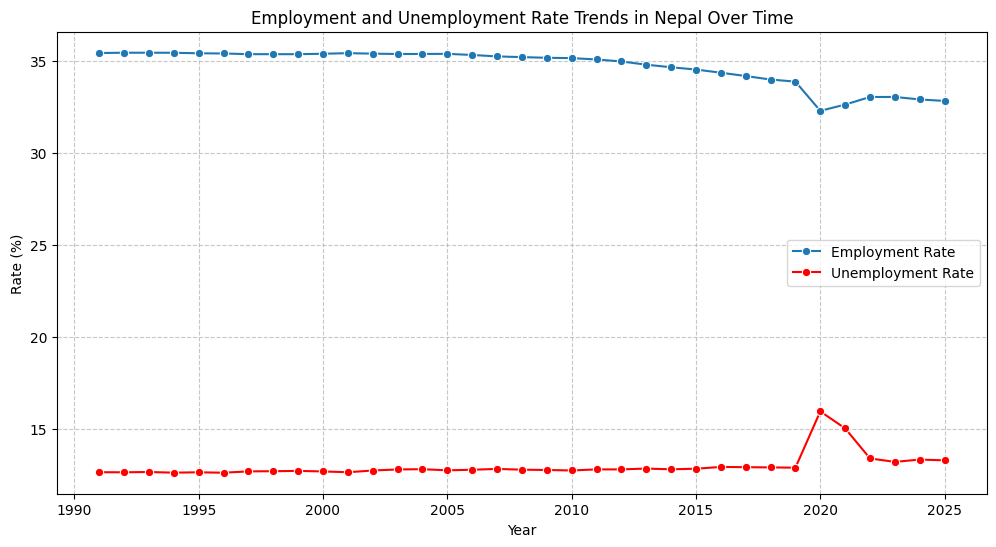

In [38]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='employment_rate', data=nepal_yearly_trends, label='Employment Rate', marker='o')
sns.lineplot(x='year', y='unemployment_rate', data=nepal_yearly_trends, label='Unemployment Rate', marker='o', color='red')
plt.title('Employment and Unemployment Rate Trends in Nepal Over Time')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [39]:
continent_mapping = {
    'Afghanistan': 'Asia',
    'Angola': 'Africa',
    'Albania': 'Europe',
    'United Arab Emirates': 'Asia',
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Azerbaijan': 'Asia',
    'Burundi': 'Africa',
    'Belgium': 'Europe',
    'Benin': 'Africa',
    'Burkina Faso': 'Africa',
    'Bangladesh': 'Asia',
    'Bulgaria': 'Europe',
    'Bahrain': 'Asia',
    'Bahamas': 'North America',
    'Bosnia and Herzegovina': 'Europe',
    'Belarus': 'Europe',
    'Belize': 'North America',
    'Bolivia (Plurinational State of)': 'South America',
    'Brazil': 'South America',
    'Barbados': 'North America',
    'Brunei Darussalam': 'Asia',
    'Bhutan': 'Asia',
    'Botswana': 'Africa',
    'Central African Republic': 'Africa',
    'Canada': 'North America',
    'Switzerland': 'Europe',
    'Chile': 'South America',
    'China': 'Asia',
    "Côte d'Ivoire": 'Africa',
    'Cameroon': 'Africa',
    'Congo, Democratic Republic of the': 'Africa',
    'Congo': 'Africa',
    'Colombia': 'South America',
    'Comoros': 'Africa',
    'Cabo Verde': 'Africa',
    'Costa Rica': 'North America',
    'Cuba': 'North America',
    'Cyprus': 'Europe',
    'Czechia': 'Europe',
    'Germany': 'Europe',
    'Djibouti': 'Africa',
    'Denmark': 'Europe',
    'Dominican Republic': 'North America',
    'Algeria': 'Africa',
    'Ecuador': 'South America',
    'Egypt': 'Africa',
    'Eritrea': 'Africa',
    'Western Sahara': 'Africa',
    'Spain': 'Europe',
    'Estonia': 'Europe',
    'Ethiopia': 'Africa',
    'Finland': 'Europe',
    'Fiji': 'Oceania',
    'France': 'Europe',
    'Gabon': 'Africa',
    'United Kingdom of Great Britain and Northern Ireland': 'Europe',
    'Georgia': 'Asia',
    'Ghana': 'Africa',
    'Guinea': 'Africa',
    'Gambia': 'Africa',
    'Guinea-Bissau': 'Africa',
    'Equatorial Guinea': 'Africa',
    'Greece': 'Europe',
    'Guatemala': 'North America',
    'Guyana': 'South America',
    'Hong Kong, China': 'Asia',
    'Honduras': 'North America',
    'Croatia': 'Europe',
    'Haiti': 'North America',
    'Hungary': 'Europe',
    'Indonesia': 'Asia',
    'India': 'Asia',
    'Ireland': 'Europe',
    'Iran (Islamic Republic of)': 'Asia',
    'Iraq': 'Asia',
    'Iceland': 'Europe',
    'Israel': 'Asia',
    'Italy': 'Europe',
    'Jamaica': 'North America',
    'Jordan': 'Asia',
    'Japan': 'Asia',
    'Kazakhstan': 'Asia',
    'Kenya': 'Africa',
    'Kyrgyzstan': 'Asia',
    'Cambodia': 'Asia',
    'Republic of Korea': 'Asia',
    'Kuwait': 'Asia',
    "Lao People's Democratic Republic": 'Asia',
    'Lebanon': 'Asia',
    'Liberia': 'Africa',
    'Libya': 'Africa',
    'Saint Lucia': 'North America',
    'Sri Lanka': 'Asia',
    'Lesotho': 'Africa',
    'Lithuania': 'Europe',
    'Luxembourg': 'Europe',
    'Latvia': 'Europe',
    'Macao, China': 'Asia',
    'Morocco': 'Africa',
    'Republic of Moldova': 'Europe',
    'Madagascar': 'Africa',
    'Maldives': 'Asia',
    'Mexico': 'North America',
    'North Macedonia': 'Europe',
    'Mali': 'Africa',
    'Malta': 'Europe',
    'Myanmar': 'Asia',
    'Montenegro': 'Europe',
    'Mongolia': 'Asia',
    'Mozambique': 'Africa',
    'Mauritania': 'Africa',
    'Mauritius': 'Africa',
    'Malawi': 'Africa',
    'Malaysia': 'Asia',
    'Namibia': 'Africa',
    'Niger': 'Africa',
    'Nigeria': 'Africa',
    'Nicaragua': 'North America',
    'Netherlands': 'Europe',
    'Norway': 'Europe',
    'Nepal': 'Asia',
    'New Zealand': 'Oceania',
    'Oman': 'Asia',
    'Pakistan': 'Asia',
    'Panama': 'North America',
    'Peru': 'South America',
    'Philippines': 'Asia',
    'Papua New Guinea': 'Oceania',
    'Poland': 'Europe',
    "Korea (the Democratic People's Republic of)": 'Asia', # Fixed syntax error here
    'Portugal': 'Europe',
    'Paraguay': 'South America',
    'Palestine (State of)': 'Asia',
    'Qatar': 'Asia',
    'Romania': 'Europe',
    'Russian Federation': 'Europe',
    'Rwanda': 'Africa',
    'Saudi Arabia': 'Asia',
    'Sudan': 'Africa',
    'Senegal': 'Africa',
    'Singapore': 'Asia',
    'Solomon Islands': 'Oceania',
    'Sierra Leone': 'Africa',
    'El Salvador': 'North America',
    'Somalia': 'Africa',
    'Serbia': 'Europe',
    'South Sudan': 'Africa',
    'Sao Tome and Principe': 'Africa',
    'Suriname': 'South America',
    'Slovakia': 'Europe',
    'Slovenia': 'Europe',
    'Sweden': 'Europe',
    'Eswatini': 'Africa',
    'Syrian Arab Republic': 'Asia',
    'Chad': 'Africa',
    'Togo': 'Africa',
    'Thailand': 'Asia',
    'Tajikistan': 'Asia',
    'Turkmenistan': 'Asia',
    'Timor-Leste': 'Asia',
    'Tonga': 'Oceania',
    'Trinidad and Tobago': 'North America',
    'Tunisia': 'Africa',
    'Türkiye': 'Asia',
    'Taiwan, China': 'Asia',
    'Tanzania, United Republic of': 'Africa',
    'Uganda': 'Africa',
    'Ukraine': 'Europe',
    'Uruguay': 'South America',
    'United States of America': 'North America',
    'Uzbekistan': 'Asia',
    'Saint Vincent and the Grenadines': 'North America',
    'Venezuela (Bolivarian Republic of)': 'South America',
    'Viet Nam': 'Asia',
    'Vanuatu': 'Oceania',
    'Samoa': 'Oceania',
    'Yemen': 'Asia',
    'South Africa': 'Africa',
    'Zambia': 'Africa',
    'Zimbabwe': 'Africa'
}

df_cleaned['continent'] = df_cleaned['country'].map(continent_mapping)

# Check for any countries that couldn't be mapped (NaN in 'continent' column)
unmapped_countries = df_cleaned[df_cleaned['continent'].isnull()]['country'].unique()
if len(unmapped_countries) > 0:
    print(f"Warning: The following countries could not be mapped to a continent: {unmapped_countries}")

display(df_cleaned.head())

,iso_code,country,year,employment_rate,unemployment_rate,continent
0,AFG,Afghanistan,2025,32.457,13.351,Asia
1,AFG,Afghanistan,2025,32.457,16.785,Asia
2,AFG,Afghanistan,2025,32.457,11.340,Asia
3,AFG,Afghanistan,2025,32.457,12.503,Asia
4,AFG,Afghanistan,2025,32.457,15.814,Asia


In [40]:
continent_employment = df_cleaned.groupby('continent')['employment_rate'].mean().reset_index()
continent_employment = continent_employment.sort_values(by='employment_rate', ascending=False)

print("Average Employment Rate by Continent:")
display(continent_employment)

Average Employment Rate by Continent:


,continent,employment_rate
4,Oceania,57.359362
3,North America,54.477738
5,South America,54.393028
0,Africa,54.231146
1,Asia,52.213149
2,Europe,48.682483


In [41]:
from scipy.stats import f_oneway, kruskal

print("\n=== STATISTICAL COMPARISON OF CONTINENTS ===")

# Get data for each continent
continents = df_cleaned['continent'].unique()
continent_data = [df_cleaned[df_cleaned['continent'] == c]['employment_rate'].dropna()
                  for c in continents]

# ANOVA (parametric test)
f_stat, anova_p = f_oneway(*continent_data)
print(f"\n1. One-Way ANOVA:")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   P-value: {anova_p:.6f}")
print(f"   Result: {'Continents differ SIGNIFICANTLY' if anova_p < 0.05 else 'No significant difference'}")

# Kruskal-Wallis (non-parametric - better for non-normal data)
h_stat, kw_p = kruskal(*continent_data)
print(f"\n2. Kruskal-Wallis Test (non-parametric - RECOMMENDED):")
print(f"   H-statistic: {h_stat:.4f}")
print(f"   P-value: {kw_p:.6f}")
print(f"   Result: {'Continents differ SIGNIFICANTLY' if kw_p < 0.05 else 'No significant difference'}")
if anova_p < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    print(f"\n3. Post-hoc Pairwise Comparisons (Tukey HSD):")
    tukey_data = df_cleaned[['continent', 'employment_rate']].dropna()
    tukey_result = pairwise_tukeyhsd(tukey_data['employment_rate'],
                                     tukey_data['continent'],
                                     alpha=0.05)
    print(tukey_result)


=== STATISTICAL COMPARISON OF CONTINENTS ===

1. One-Way ANOVA:
   F-statistic: 1550.0287
   P-value: 0.000000
   Result: Continents differ SIGNIFICANTLY

2. Kruskal-Wallis Test (non-parametric - RECOMMENDED):
   H-statistic: 8578.5309
   P-value: 0.000000
   Result: Continents differ SIGNIFICANTLY

3. Post-hoc Pairwise Comparisons (Tukey HSD):
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
       Africa          Asia   -2.018    0.0 -2.2241 -1.8119   True
       Africa        Europe  -5.5487    0.0 -5.7677 -5.3296   True
       Africa North America   0.2466 0.1206 -0.0332  0.5264  False
       Africa       Oceania   3.1282    0.0  2.7309  3.5255   True
       Africa South America   0.1619 0.7401 -0.1728  0.4965  False
         Asia        Europe  -3.5307    0.0 -3.7535 -3.3078   True
         Asia North America   2.2646    0.0  1.98

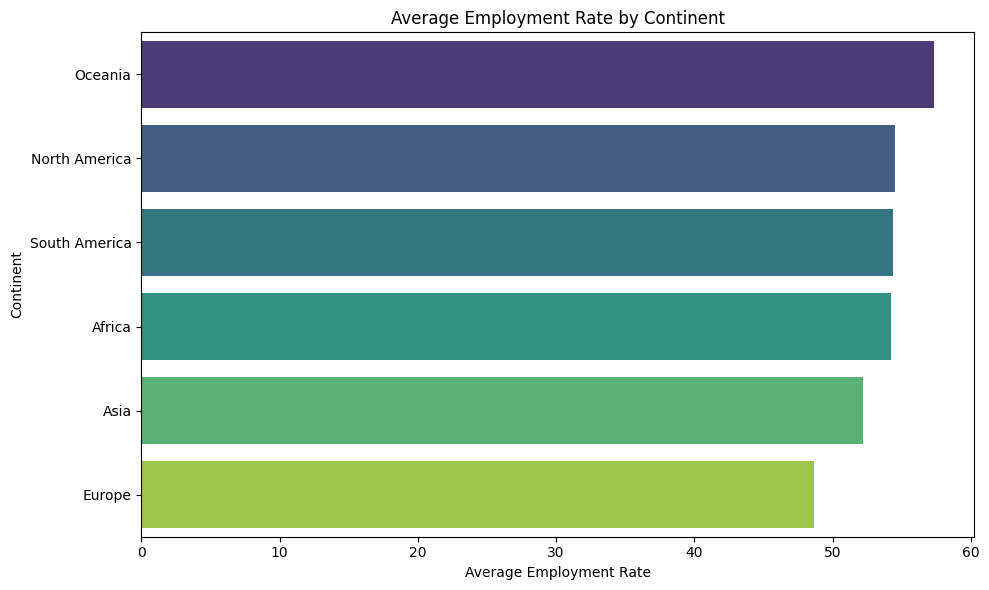

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(x='employment_rate', y='continent', data=continent_employment, hue='continent', palette='viridis', legend=False)
plt.title('Average Employment Rate by Continent')
plt.xlabel('Average Employment Rate')
plt.ylabel('Continent')
plt.tight_layout()
plt.show()

In [43]:
continent_rates_avg = df_cleaned.groupby('continent')[['employment_rate', 'unemployment_rate']].mean().reset_index()

print("Average Employment and Unemployment Rates by Continent:")
display(continent_rates_avg)

Average Employment and Unemployment Rates by Continent:


,continent,employment_rate,unemployment_rate
0,Africa,54.231146,11.645406
1,Asia,52.213149,8.158194
2,Europe,48.682483,12.733265
3,North America,54.477738,10.772307
4,Oceania,57.359362,5.841539
5,South America,54.393028,10.782929


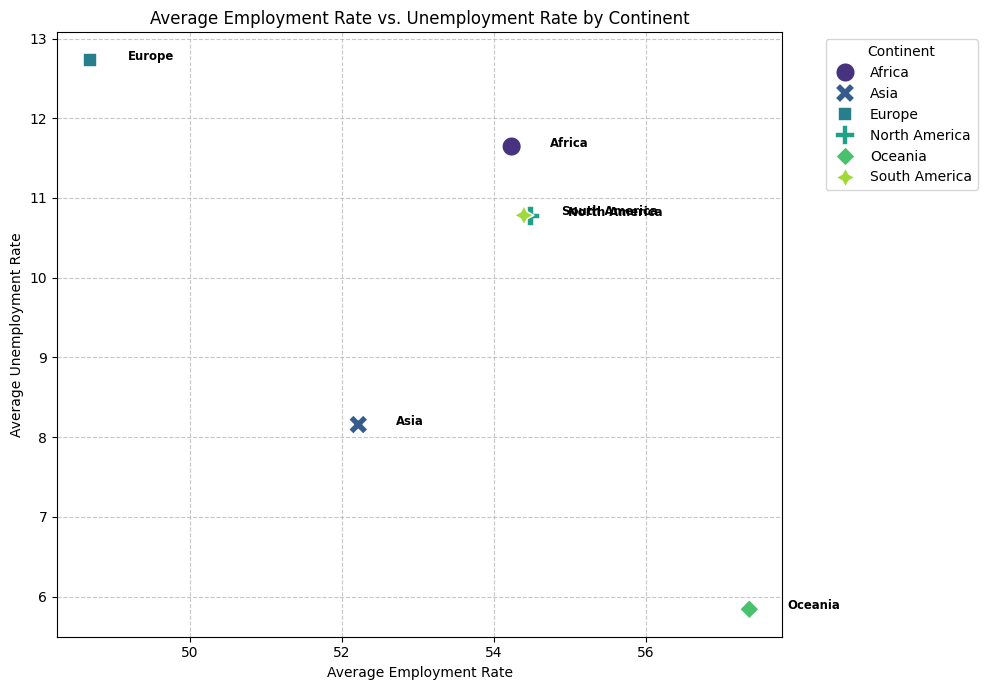

In [44]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='employment_rate', y='unemployment_rate', data=continent_rates_avg, hue='continent', s=200, style='continent', palette='viridis')

for i, row in continent_rates_avg.iterrows():
    plt.text(row['employment_rate'] + 0.5, row['unemployment_rate'], row['continent'], horizontalalignment='left', size='small', color='black', weight='semibold')

plt.title('Average Employment Rate vs. Unemployment Rate by Continent')
plt.xlabel('Average Employment Rate')
plt.ylabel('Average Unemployment Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()